In [12]:
#Libraries
import os 
from dotenv import load_dotenv
from typing import Literal
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.prebuilt import ToolNode
from IPython.display import display, Image

#Load environment
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

#Instantiate llm model
#We use a lower temperature for the agent to ensure precise tool usage
llm = ChatOpenAI(model="gpt-4o", api_key=api_key, temperature=0)
print(llm.model_name)

gpt-4o


In [13]:
#Define our retrieval tool
@tool
def retrieve_support_policy(query: str) -> str:
    """
    Search the customer support knowledge base for troubleshooting steps and policies.
    Use this tool when users report technical issues (like 'laptop wont turn on') 
    or ask about return policies.
    """
    # This simulates searching a VectorStore
    # In production, replace this with vectorstore.similarity_search(query)
    print(f"DEBUG: Searching knowledge base for: '{query}'")
    
    knowledge_base = {
        "laptop": "troubleshooting steps: 1. Check power source. 2. Inspect charger. 3. Hold power button for 15s (Hard Reset).",
        "return": "You have a 30-day return window for all electronics. Receipt required.",
        "screen": "If the screen is black but lights are on, try connecting an external monitor."
    }
    
    # Simple keyword matching simulation
    for key, value in knowledge_base.items():
        if key in query.lower():
            return f"Retrieved Document: {value}"
            
    return "No relevant documents found in the knowledge base."

#Bind tools to LLM
tools = [retrieve_support_policy]
llm_with_tools = llm.bind_tools(tools)
print("Tools bound to LLM")

Tools bound to LLM


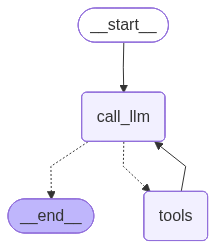

In [14]:
#create system message
#We explicitly instruct the agent on WHEN to use retrieval
sys_message = """You are a helpful customer support assistant. 

DECISION RULES:
- If the user asks a general question or says hello, answer directly.
- If the user reports a specific technical issue or asks about policy, USE the 'retrieve_support_policy' tool.
- Always base your technical advice on the retrieved information."""

#create node to call llm (The "Assistant")
def call_llm(state: MessagesState) -> dict:
    """
    Node to make calls to our llms.
    Decides whether to retrieve docs or answer.
    """
    messages = [SystemMessage(content=sys_message)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

#create conditional edge logic
def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    """
    Decides if we need to run tools or end the conversation.
    """
    last_message = state["messages"][-1]
    
    if last_message.tool_calls:
        return "tools"
    return "__end__"

#Initialize our graph
graph = StateGraph(MessagesState)

#Add nodes and edges to graph
graph.add_node("call_llm", call_llm)
graph.add_node("tools", ToolNode(tools)) # Prebuilt node to execute tools

#Define flow: START -> call_llm -> (Decision) -> tools -> call_llm
graph.add_edge(START, "call_llm")
graph.add_conditional_edges(
    "call_llm",
    should_continue,
    {"tools": "tools", "__end__": END}
)
graph.add_edge("tools", "call_llm") # Loop back to assistant after retrieval

#Memory Saver checkpointer for memory
memory = MemorySaver()
agent = graph.compile(checkpointer=memory)

#Visualize graph
#This now shows the cyclic nature of Agentic RAG
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph compiled (Visualization skipped)")

In [17]:
#Main code segment(where the magic happens)
#Customer Agent chatbot

def run_conversation(user_input:str, thread_id: str = "user_002"):
    print(f"\n{'='*50}")
    print(f"User: {user_input}")
    
    #Run our graph
    response = agent.invoke({"messages": HumanMessage(user_input)},
                            config={"configurable":{"thread_id": thread_id}})
    
    #Print out responses (filtered for clarity)
    messages = response["messages"]
    
    # We loop through to show the agent's thought process
    for message in messages:
        if isinstance(message, AIMessage):
            if message.tool_calls:
                print(f"AI Status: [Decided to search knowledge base...]")
            elif message.content:
                print(f"AI Response: {message.content}")
        elif isinstance(message, ToolMessage):
             print(f"System: [Data retrieved]")

#Test chatbot
#1. General Greeting (Should NOT retrieve)
run_conversation("Hi, my name is David and I like programming.")

#2. RAG Query (Should trigger retrieval tool)
run_conversation("I bought a laptop last week and it won't turn on. What should I do?")


User: Hi, my name is David and I like programming.
AI Response: Hello David! It's great to hear that you like programming. Is there anything specific you'd like to discuss or any questions you have about programming?

User: I bought a laptop last week and it won't turn on. What should I do?
DEBUG: Searching knowledge base for: 'laptop won't turn on troubleshooting'
AI Response: Hello David! It's great to hear that you like programming. Is there anything specific you'd like to discuss or any questions you have about programming?
AI Status: [Decided to search knowledge base...]
System: [Data retrieved]
AI Response: Here are some troubleshooting steps you can try if your laptop won't turn on:

1. **Check the Power Source**: Ensure that the power outlet is working by plugging in another device. Also, make sure the laptop's power cable is securely connected.

2. **Inspect the Charger**: Check the charger for any visible damage. If possible, try using a different charger to see if that reso

Model initialized: gpt-4o


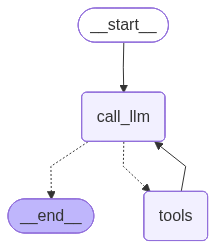


User: Hi, I am David.
AI Response: Hello David! How can I assist you today?

User: I bought a laptop last week and it won't turn on.
DEBUG: Agent is retrieving data for: 'laptop won't turn on troubleshooting'
AI Response: Hello David! How can I assist you today?
AI Status: [Calling Tool: retrieve_docs...]
System: [Tool Output Received]
AI Response: Here are some troubleshooting steps you can try if your laptop won't turn on:

1. **Check the Power Cable**: Ensure that the power cable is securely connected to both the laptop and the power outlet. Try using a different power outlet if possible.

2. **Hold the Power Button**: Press and hold the power button for about 15 seconds. This can sometimes reset the laptop and help it start.

3. **Check the Battery Indicator**: If your laptop has a battery indicator light, check to see if it's on or flashing. This can give you a clue about whether the battery is charging or if there's a power issue.

Try these steps and let me know if your laptop 